# 05 Screening for Covarying G-Gene Sites

**Methods mapping:** screening for covarying G-gene sites.

The validation samples are defined from haplotype FASTA files and TreeCluster branch assignments. The linked sites are then screened from the full raw LoFreq iSNV CSV by recurrence in that selected validation set; no prepared linked-site list is used as input.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT


PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes')

In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('05_screening_for_covarying_g_gene_sites', ROOT)
INPUTS = {
    "lofreq_raw_calls": ROOT / "data/input/isnv/lofreq_raw_calls.csv",
    "metadata": ROOT / "data/metadata/meta_v6_with_season_clade.csv",
    "AU_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1037681_extracted_4652-5617.fasta",
    "US_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1130896_extracted_4652-5617.fasta",
}
OUTPUTS = {
    "selected_validation_samples": DATA_DIR / "selected_linked_isnv_validation_samples.csv",
    "linked_site_screen": DATA_DIR / "linked_site_screen_from_lofreq.csv",
    "targeted_frequencies": DATA_DIR / "targeted_site_frequencies_from_lofreq.csv",
    "frequency_summary": DATA_DIR / "targeted_site_frequency_summary.csv",
    "pairwise_correlations": DATA_DIR / "targeted_site_pairwise_pearson_correlations.csv",
    "strong_pairs": DATA_DIR / "targeted_site_pairs_abs_r_ge_0p8.csv",
    "figure_png": FIG_DIR / "Fig2A_allele_frequency_validation.png",
    "figure_pdf": FIG_DIR / "Fig2A_allele_frequency_validation.pdf",
    "figure_svg": FIG_DIR / "Fig2A_allele_frequency_validation.svg",
}


def show_paths(title, paths):
    rows = []
    for name, path in paths.items():
        path = Path(path)
        rows.append({"name": name, "relative_path": rel(path), "exists": path.exists()})
    display(Markdown(f"### {title}"))
    display(pd.DataFrame(rows))

for path in OUTPUTS.values():
    Path(path).parent.mkdir(parents=True, exist_ok=True)

show_paths("Input paths", INPUTS)
show_paths("Output paths", OUTPUTS)
DATA_DIR, FIG_DIR


### Input paths

,name,relative_path,exists
0,lofreq_raw_calls,data/input/isnv/lofreq_raw_calls.csv,True
1,metadata,data/metadata/meta_v6_with_season_clade.csv,True
2,AU_haplotype_fasta,data/input/haplotypes/PRJNA1037681_...,True
3,US_haplotype_fasta,data/input/haplotypes/PRJNA1130896_...,True


### Output paths

,name,relative_path,exists
0,selected_validation_samples,data/processed_data/05_screening_for_cov...,True
1,linked_site_screen,data/processed_data/05_screening_for_cov...,True
2,targeted_frequencies,data/processed_data/05_screening_for_cov...,True
3,frequency_summary,data/processed_data/05_screening_for_cov...,True
4,pairwise_correlations,data/processed_data/05_screening_for_cov...,True
5,strong_pairs,data/processed_data/05_screening_for_cov...,True
6,figure_png,results/figures/05_screening_for_co...,True
7,figure_pdf,results/figures/05_screening_for_co...,True
8,figure_svg,results/figures/05_screening_for_co...,True


(PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/data/processed_data/05_screening_for_covarying_g_gene_sites'),
 PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/results/figures/05_screening_for_covarying_g_gene_sites'))

## Derive Validation Samples and Candidate Sites

The focal branch combinations are selected from observed sample-level TreeCluster combinations. The linked-site screen then looks for recurrent G-region SNVs in those samples.


In [3]:
targets = au.select_target_branch_combos(ROOT)
selected_samples = au.selected_linked_validation_samples(ROOT)
site_sets = au.derive_linked_site_sets(ROOT)
site_screen = getattr(au.derive_linked_site_sets, 'last_screen_table')

display(targets)
display(selected_samples[['project', 'SampleID', 'selected_TreeCluster_combo', 'collection_date', 'clade', 'global_short_label']].head())
display(site_screen)


,project,project_label,target_combo,target_branches,n_target_samples,selection_rule
0,PRJNA1037681,Australia,C4+C6,"[C4, C6]",23,most frequent exact cross-branch TreeCluster c...
1,PRJNA1130896,United States,C18+C21,"[C18, C21]",26,most frequent exact cross-branch TreeCluster c...


,project,SampleID,selected_TreeCluster_combo,collection_date,clade,global_short_label
0,PRJNA1037681,SRR26779971,C4+C6,2022/5/15,A.D.3.1,AU-S01
1,PRJNA1037681,SRR26780187,C4+C6,2022/5/16,A.D.3.1,AU-S02
2,PRJNA1037681,SRR26780146,C4+C6,2022/5/28,A.D.3.1,AU-S03
3,PRJNA1037681,SRR26780067,C4+C6,2022/5/30,A.D.3.1,AU-S04
4,PRJNA1037681,SRR26780216,C4+C6,2022/6/1,A.D.3.1,AU-S05


,project,project_label,position,Reference,Allele,samples_with_candidate_iSNV,n_validation_samples,min_samples_required,recurrence_fraction,median_AF,min_AF,max_AF,median_DP,screen_rule
0,PRJNA1037681,Australia,5510,G,A,22,23,20,0.956522,0.050171,0.031902,0.085859,821.0,G SNV; 0.03<=AF<0.97; recurrent in >= 85% of v...
1,PRJNA1037681,Australia,5520,A,T,23,23,20,1.000000,0.062299,0.031716,0.106090,799.0,G SNV; 0.03<=AF<0.97; recurrent in >= 85% of v...
2,PRJNA1037681,Australia,5544,C,T,23,23,20,1.000000,0.930131,0.868119,0.957921,729.0,G SNV; 0.03<=AF<0.97; recurrent in >= 85% of v...
3,PRJNA1037681,Australia,5558,G,A,21,23,20,0.913043,0.948718,0.895906,0.966292,728.0,G SNV; 0.03<=AF<0.97; recurrent in >= 85% of v...
4,PRJNA1037681,Australia,5563,T,C,20,23,20,0.869565,0.046804,0.036660,0.093836,744.5,G SNV; 0.03<=AF<0.97; recurrent in >= 85% of v...
5,PRJNA1130896,United States,5531,T,C,26,26,23,1.000000,0.870405,0.743728,0.915636,3807.0,G SNV; 0.03<=AF<0.97; recurrent in >= 85% of v...
6,PRJNA1130896,United States,5561,T,C,26,26,23,1.000000,0.850798,0.697757,0.911309,3088.0,G SNV; 0.03<=AF<0.97; recurrent in >= 85% of v...


## Generate Targeted Frequencies and Correlations

For every selected sample and linked site, this cell pulls the target allele frequency from the raw LoFreq calls and computes pairwise correlations.


In [4]:
freq, summary, correlations = au.covarying_site_screening(ROOT, DATA_DIR)

display(freq.head())
display(summary)
display(correlations.head(15))


,project,project_label,project_short,SampleID,global_short_label,validation_sample_set,selected_TreeCluster_combo,collection_date,year_month,clade,position,aa_position,Reference,Allele,lofreq_status,other_alts_at_position,AF,plot_AF,target_allele_frequency_percent,reference_allele_frequency_percent,alt_frequency_percent,ref_frequency_percent,DP,ref_depth,alt_depth,QUAL,FILTER
0,PRJNA1037681,Australia,AU,SRR26779971,AU-S01,AU linked iSNV validation set,C4+C6,2022/5/15,2022-05,A.D.3.1,5510,287,G,A,called_target_alt,A,0.045455,0.045455,4.5455,95.4545,4.5455,95.4545,638.0,608.0,29.0,424,PASS
1,PRJNA1037681,Australia,AU,SRR26779971,AU-S01,AU linked iSNV validation set,C4+C6,2022/5/15,2022-05,A.D.3.1,5520,290,A,T,called_target_alt,T,0.055016,0.055016,5.5016,94.4984,5.5016,94.4984,618.0,584.0,34.0,622,PASS
2,PRJNA1037681,Australia,AU,SRR26779971,AU-S01,AU linked iSNV validation set,C4+C6,2022/5/15,2022-05,A.D.3.1,5544,298,C,T,called_target_alt,T,0.940496,0.940496,94.0496,5.9504,94.0496,5.9504,605.0,36.0,569.0,20620,PASS
3,PRJNA1037681,Australia,AU,SRR26779971,AU-S01,AU linked iSNV validation set,C4+C6,2022/5/15,2022-05,A.D.3.1,5558,303,G,A,called_target_alt,A,0.953947,0.953947,95.3947,4.6053,95.3947,4.6053,608.0,28.0,580.0,20810,PASS
4,PRJNA1037681,Australia,AU,SRR26779971,AU-S01,AU linked iSNV validation set,C4+C6,2022/5/15,2022-05,A.D.3.1,5563,304,T,C,called_target_alt,C,0.045752,0.045752,4.5752,95.4248,4.5752,95.4248,612.0,584.0,28.0,545,PASS


,project,project_label,validation_sample_set,selected_TreeCluster_combo,position,aa_position,Reference,Allele,lofreq_status,samples,median_alt_frequency_percent,min_alt_frequency_percent,max_alt_frequency_percent,median_depth
0,PRJNA1037681,Australia,AU linked iSNV validation set,C4+C6,5510,287,G,A,called_target_alt,23,4.95570,2.7127,8.5859,827.0
1,PRJNA1037681,Australia,AU linked iSNV validation set,C4+C6,5520,290,A,T,called_target_alt,23,6.22990,3.1716,10.6090,799.0
2,PRJNA1037681,Australia,AU linked iSNV validation set,C4+C6,5544,298,C,T,called_target_alt,23,93.01310,86.8119,95.7921,729.0
3,PRJNA1037681,Australia,AU linked iSNV validation set,C4+C6,5558,303,G,A,called_target_alt,23,94.91760,89.5906,97.3594,759.0
4,PRJNA1037681,Australia,AU linked iSNV validation set,C4+C6,5563,304,T,C,called_target_alt,23,4.48180,2.3364,9.3836,763.0
5,PRJNA1130896,United States,US linked iSNV validation set,C18+C21,5531,294,T,C,called_target_alt,26,87.04055,74.3728,91.5636,3807.0
6,PRJNA1130896,United States,US linked iSNV validation set,C18+C21,5561,304,T,C,called_target_alt,26,85.07980,69.7757,91.1309,3088.0


,project,project_label,position_a,position_b,n_samples,pearson_r,abs_pearson_r
9,PRJNA1037681,Australia,5558,5563,23,-0.963757,0.963757
7,PRJNA1037681,Australia,5544,5558,23,0.920192,0.920192
4,PRJNA1037681,Australia,5520,5544,23,-0.880299,0.880299
8,PRJNA1037681,Australia,5544,5563,23,-0.880028,0.880028
0,PRJNA1037681,Australia,5510,5520,23,0.854638,0.854638
6,PRJNA1037681,Australia,5520,5563,23,0.829995,0.829995
5,PRJNA1037681,Australia,5520,5558,23,-0.823307,0.823307
3,PRJNA1037681,Australia,5510,5563,23,0.667243,0.667243
1,PRJNA1037681,Australia,5510,5544,23,-0.657603,0.657603
2,PRJNA1037681,Australia,5510,5558,23,-0.646997,0.646997


## Figure

Fig. 2A is drawn from the regenerated targeted-site frequency table.


/root/autodl-tmp/rsva-g-intrahost-haplotypes/notebooks/analysis_utils.py:1260: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


{'png': 'results/figures/05_screening_for_covarying_g_gene_sites/Fig2A_allele_frequency_validation.png',
 'pdf': 'results/figures/05_screening_for_covarying_g_gene_sites/Fig2A_allele_frequency_validation.pdf',
 'svg': 'results/figures/05_screening_for_covarying_g_gene_sites/Fig2A_allele_frequency_validation.svg'}

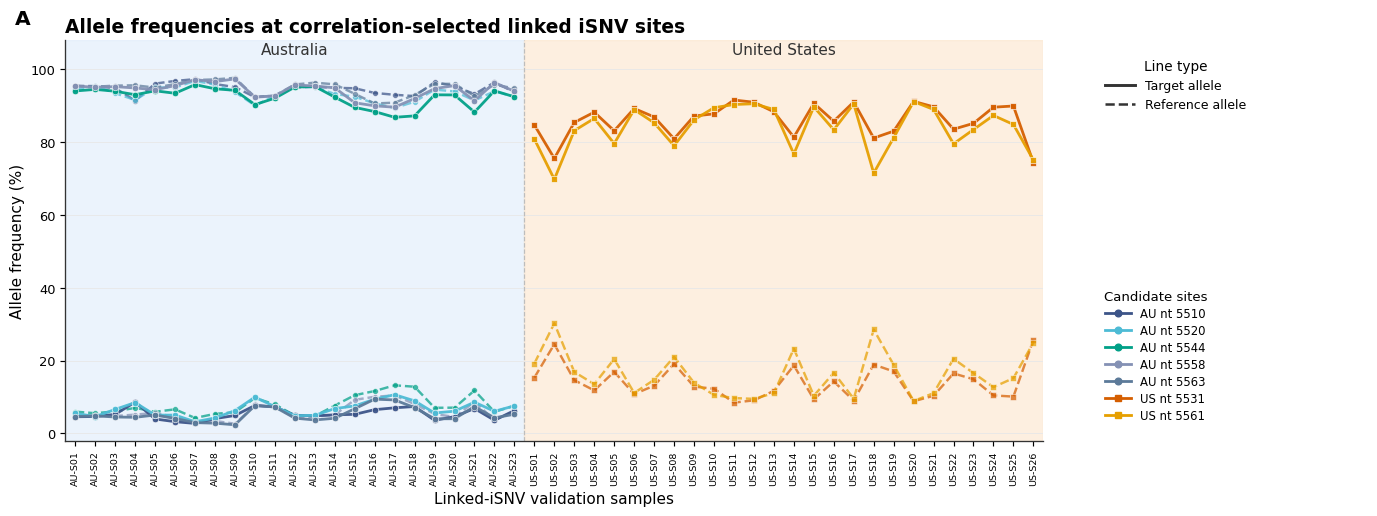

In [5]:
fig, paths = au.draw_covarying_sites(freq, correlations, FIG_DIR)
display(paths)
plt.show()
